## Bijdrage Raoul Buffels — DeepLearningTeam10

Deze Citi Bike-uitwerking is aangeleverd als de bijdrage van **Raoul Buffels**. Teamleden: Jorre Van Dyck, Milan Wouters, Raoul Buffels en Andrew Noeyens. De concrete menselijke taakverdeling moet het team zelf aanvullen. **AI-gebruik:** Codex hielp met implementatie, uitleg, tests, uitvoering en verpakking.

De codecellen zijn uitgevoerd in de oorspronkelijke lokale `Citybike_full`-omgeving op 9 oktober 2026. Deze export behoudt die echte uitvoer; alleen deze Markdown-cel is toegevoegd. Lokale paden, timings en fingerprints in de rapporten beschrijven de oorspronkelijke uitvoering. Start voor heruitvoering vanuit `SolutionRaoul/Citybike` of de map `notebooks` met de bijbehorende Python 3.11-omgeving. AWS is een afzonderlijke latere taak.

# 01 — EDA en hypothesen

Bijdragen: door team in te vullen. Dit notebook toont uitsluitend ontwikkeling; volledige uitleg staat in citybike_analysis.

In [1]:
from pathlib import Path
import sys, json
import pandas as pd
from IPython.display import display, Markdown
locations = [Path.cwd(), Path.cwd().parent, Path.cwd() / 'Citybike_full']
ROOT = next((p for p in locations if (p / 'citibike').exists()), None)
if ROOT is None: raise RuntimeError('Start dit notebook vanuit Citybike_full of notebooks.')
sys.path.insert(0, str(ROOT))
from citibike.config import REPORTS, DATA, MODELS
from citibike.datasets import manifest
from citibike.plots import show
def report(name):
    return json.loads((REPORTS / name).read_text(encoding='utf-8'))
def table(name):
    display(pd.read_csv(REPORTS / name, dtype={'start_station_id':'string','end_station_id':'string','station_id':'string'}))


NYC-vragen: tijd, ritduur, categorieën, stations, routes en geografie. Iedere interpretatie wordt uit de berekende uitvoer gemaakt.

In [2]:
show('temporal')

<Figure size 1100x700 with 2 Axes>

De ontwikkelingsdata bevatten 303,498,919 bruikbare vertrekken. Het recente daggemiddelde is 111,039 ritten en het maximum 202,031. Groei kan samenhangen met systeemuitbreiding; dit bewijst geen oorzaak. De onvolledige eindjaren zijn niet rechtstreeks met volledige jaren vergelijkbaar.

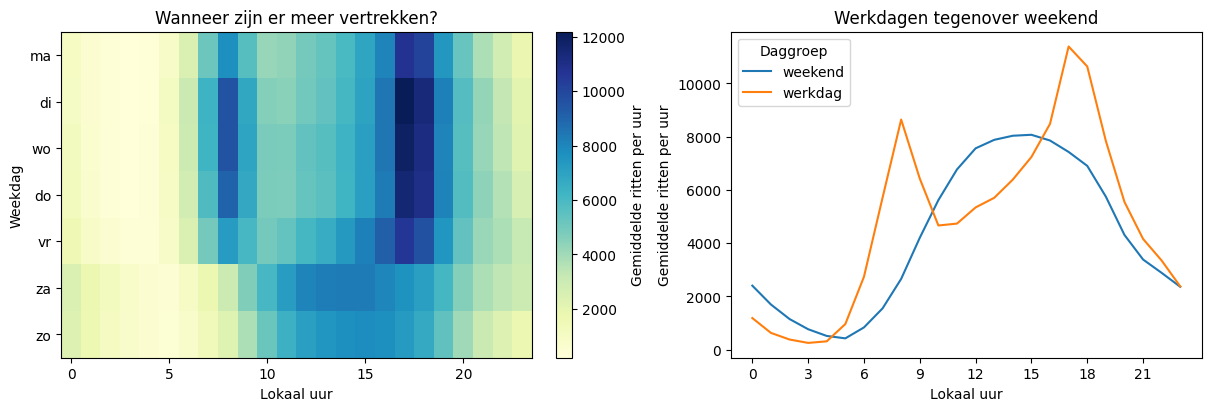

Het gemiddelde uurvolume varieert van 206.0 tot 12,186.0 ritten over de weekdag/uur-combinaties. Dit beschrijft covariatie; de geblokte hypothesetoets onderzoekt een specifiek verschil. Alleen ontwikkeling vanaf 2023 is gebruikt.

In [3]:
show('hour_weekday')

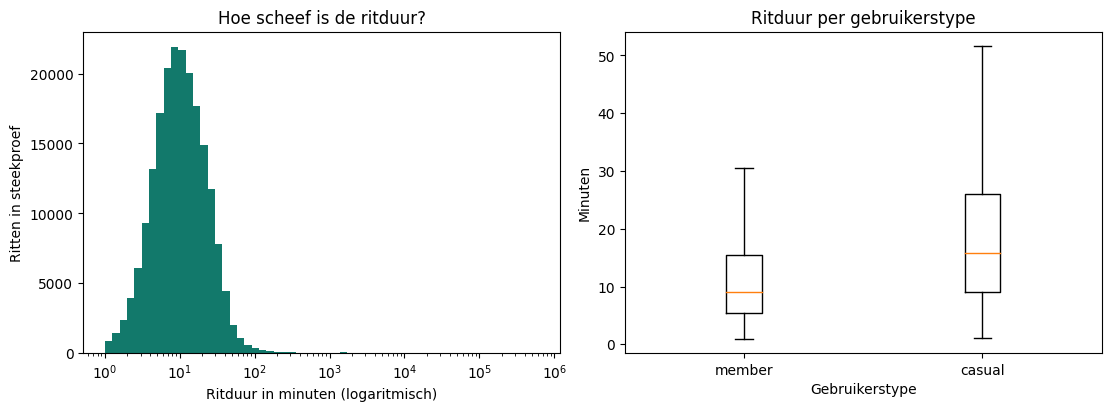

De deterministische steekproef bevat 200,000 ritten. Mediaan: 9.88 minuten; IQR: 11.56 minuten; maximum: 610,844.1 minuten. Boxplot-uitbijters worden alleen verborgen in deze weergave, niet verwijderd uit de data. Exacte groepsaantallen en benaderde volledige-data-kwantielen staan in de aggregatietabellen.

In [4]:
show('duration')

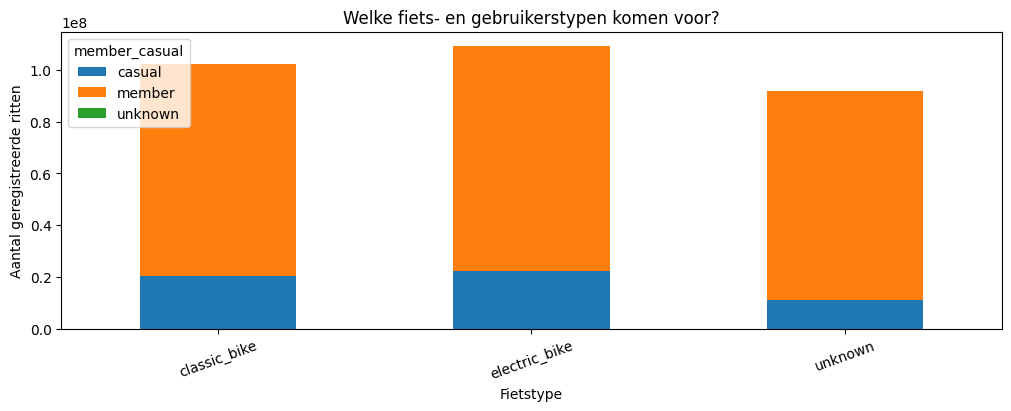

91,944,421 ritten hebben geen bekend fietstype, onder meer door het historische schema. Unknown wordt daarom niet als een echte fietscategorie geïnterpreteerd. Veranderingen in categorieën kunnen zowel gedrag als registratie weerspiegelen.

In [5]:
show('user_bike')

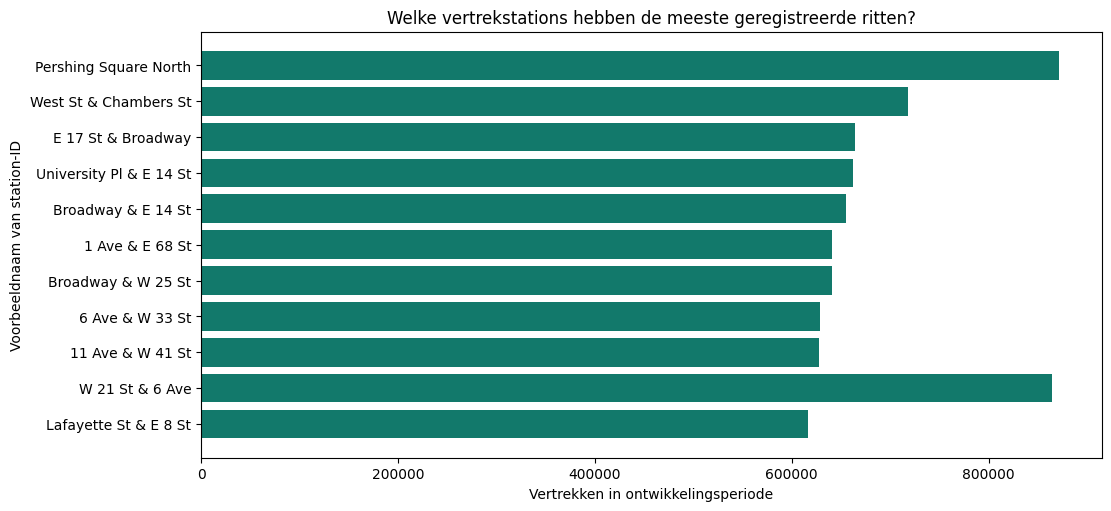

De drukste station-ID in deze aggregatie heeft 871,222 vertrekken en 3 verschillende naamlabels. Dit is een historisch totaal; stations met meer actieve jaren hebben meer gelegenheid om ritten te verzamelen. ID's uit verschillende schema's worden niet zonder bewijs samengevoegd.

In [6]:
show('stations')

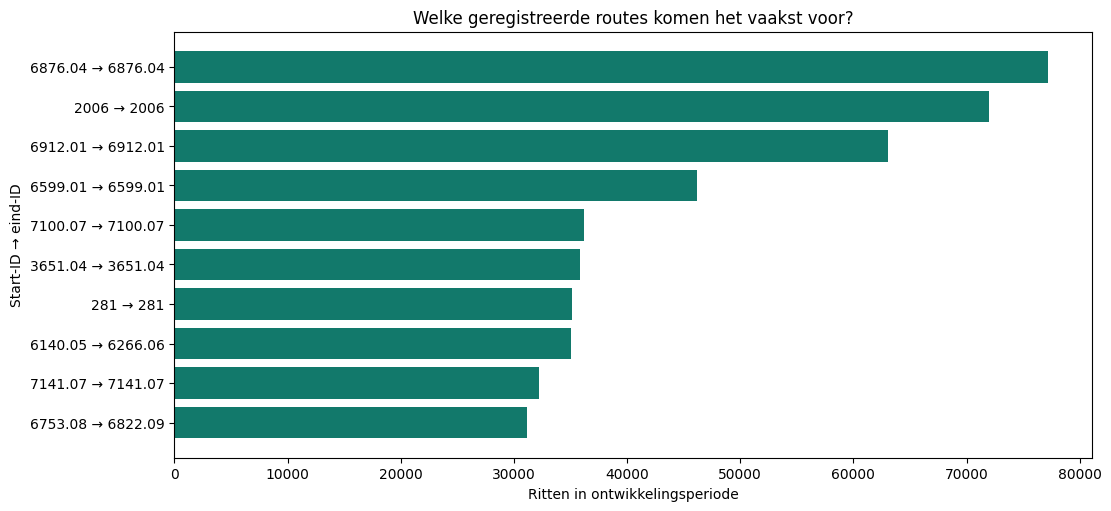

De meest voorkomende geregistreerde route heeft 77,240 ritten. Routevolumes zeggen niets over onvervulde vraag en zijn geen geschikte invoer bij vertrek als de bestemming nog onbekend is.

In [7]:
show('routes')

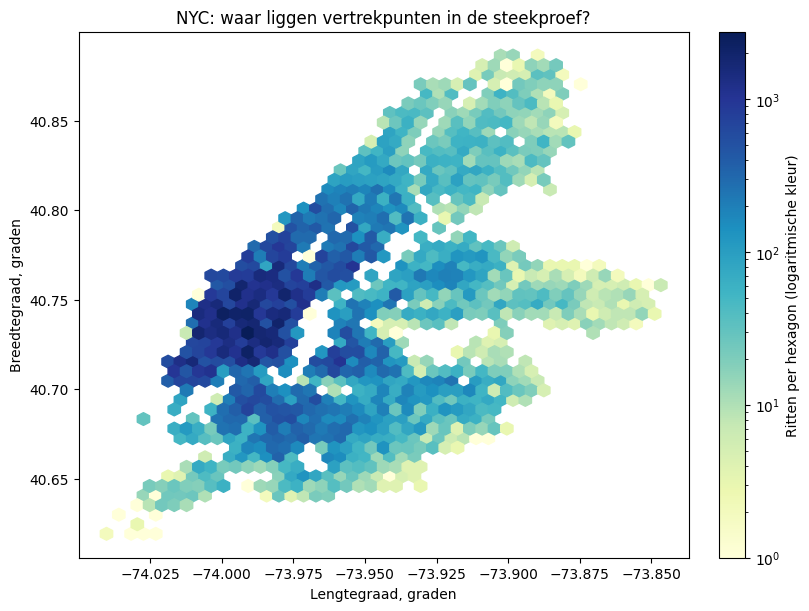

Deze geaggregeerde kaart toont 199,951 steekproefritten binnen het getoonde geografische venster. Buitenliggende punten zijn alleen buiten beeld gehouden. Geldige wereldcoördinaten zijn nog geen bewijs van een betrouwbaar NYC-station.

In [8]:
show('spatial')

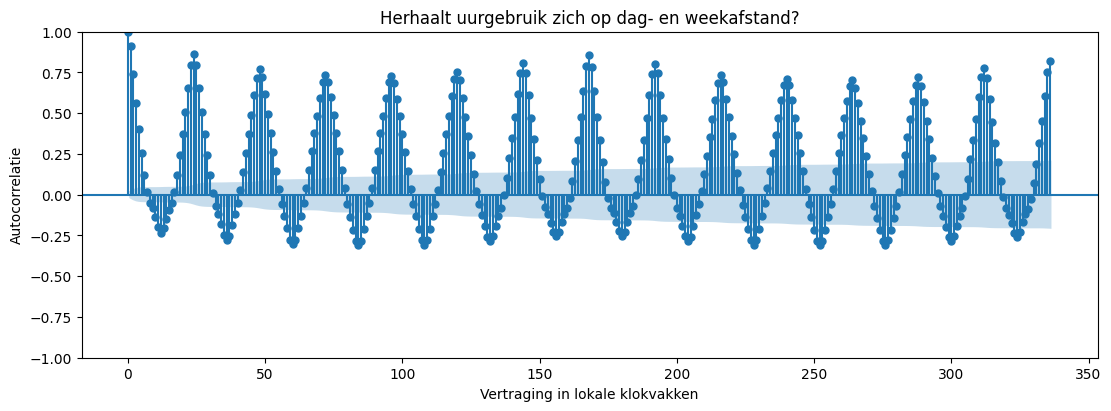

Op deze recente ontwikkelingsperiode is de autocorrelatie bij 24 uur 0.863 en bij 168 uur 0.876. Trend en seizoenen kunnen deze correlaties verhogen; dit is geen zelfstandig bewijs van voorspelprestatie. De latere modellen moeten de baseline op ongeziene perioden verslaan.

In [9]:
show('acf')

Jersey City apart; geen optelling met NYC.

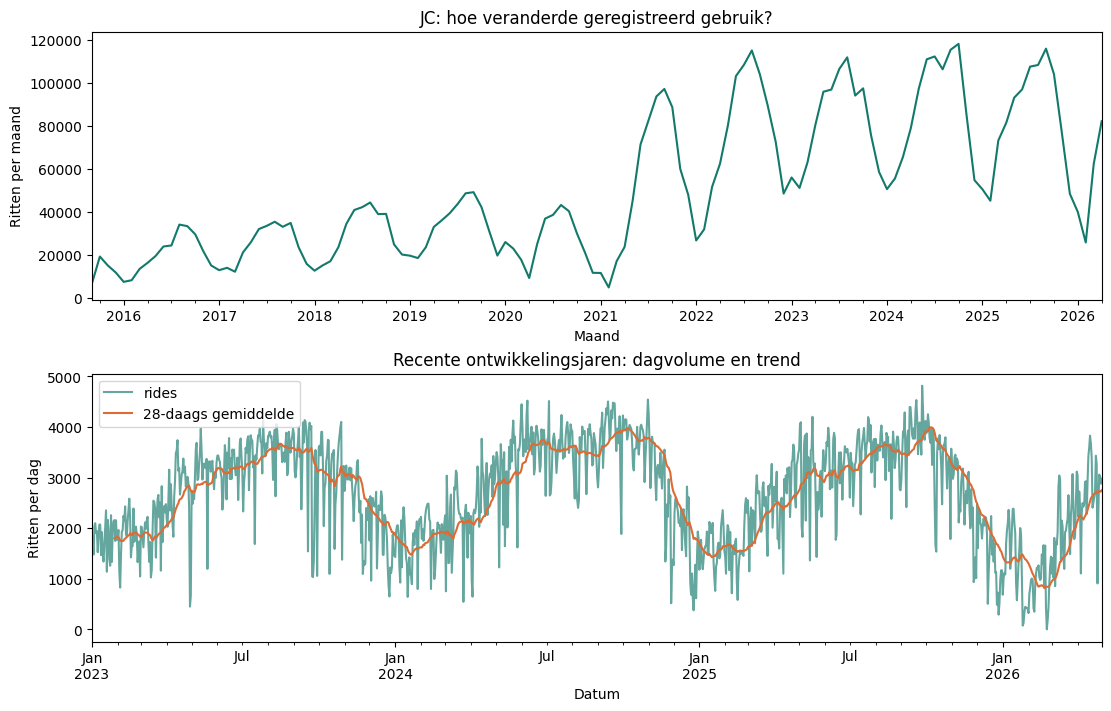

De ontwikkelingsdata bevatten 6,471,987 bruikbare vertrekken. Het recente daggemiddelde is 2,676 ritten en het maximum 4,817. Groei kan samenhangen met systeemuitbreiding; dit bewijst geen oorzaak. De onvolledige eindjaren zijn niet rechtstreeks met volledige jaren vergelijkbaar.

In [10]:
show('temporal','JC')

Geblokte hypothesen, effectgroottes, onzekerheid en Holm-correctie.

In [11]:
display(pd.DataFrame(report('hypotheses.json'))[['label','effect_size','unit','ci95','p_value','holm_p_value','reject_H0']])

,label,effect_size,unit,ci95,p_value,holm_p_value,reject_H0
0,Ochtendrit-aandeel: werkdag minus weekend,9.551946,procentpunt,"[9.088124610066025, 10.020100731495694]",0.00005,0.00015,True
1,Associatie van uurtelling met hetzelfde uur vo...,0.856100,Pearson r,"[0.8365037699140101, 0.8757808290518364]",0.00005,0.00015,True
2,Dagmediaan ritduur: casual minus member,4.014563,minuten,"[3.715054931968839, 4.320043804259509]",0.00005,0.00015,True


In [12]:
display(pd.DataFrame(report('prediction_contracts.json')['contracts']))
display(pd.DataFrame(report('target_comparison.json')))

,target,prediction_time,horizon,available,forbidden
0,hourly_demand,00:00 America/New_York op voorspeldag D,alle 24 lokale kloklabels op D (23/25 fysieke ...,kalender van D; gemeten tellingen strikt vóór D,"tellingen eerder op D, weer achteraf, eindstat..."
1,daily_demand,00:00 America/New_York op voorspeldag D,volledig dagtotaal op D,kalender van D; historie strikt vóór D,delen van dagtotaal D; informatie die pas op D...
2,duration,bij vertrek van één rit,duur tot beëindiging van deze rit (geen vaste ...,"starttijd, startstation, bekende gebruiker- en...","eindtijd, eindstation, ritduur; nog niet afger..."


,target,useful,type,target_present,unit,modeling_rows_before_features,leakage_risk,evidence,available_features,deployment,selected,data_quality,limitations
0,hourly_demand,Schat geregistreerd vertrekvolume; geen onverv...,time-series forecasting via regression,True,ritten per klokvak,113208,tellingen op D zijn verboden; alleen volledige...,weekcorrelatie 0.8561; Holm-p 0.000149993,kalender en uitsluitend afgeronde dagen,datum plus 14 volledige historische dagen,True,Aaneengesloten volledige bronmaanden en gevali...,NaN
1,daily_demand,"Dagplanning, minder detail voor piekuren",time-series forecasting via regression,True,ritten per kalenderdag,4717,delen van het huidige dagtotaal mogen niet als...,dagaggregaties en seizoenstrends onderzocht; u...,kalender en voorafgaande dagtotalen,datum plus voorafgaande dagtotalen,False,Dezelfde gevalideerde vertrekken als het uurdo...,NaN
2,duration,Verwachting bij vertrek,regression at departure,True,minuten,303478007,"eindstation, eindtijd en routeafstand achteraf...",casual-member dagmedianenverschil 4.0146 minut...,"startstation, starttijd, bekende categorieën","starttijd, startstation en bekende gebruiker/f...",False,Alleen positieve identificeerbare fysieke duur...,eindbestemming ontbreekt bij vertrek; zware st...
